<a href="https://colab.research.google.com/github/elifakgunes/NVIDIA_Module_Project/blob/main/NVIDIA_Elif_Akg%C3%BCne%C5%9F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Google Colab ve NVIDIA GPU ile yapay zeka öğrenmeye başlıyorum!")

Google Colab ve NVIDIA GPU ile yapay zeka öğrenmeye başlıyorum!


In [ ]:
# Gerekli kütüphaneleri import edelim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

# Breast Cancer veri setini yükleyelim
cancer = load_breast_cancer()

# Temel bilgileri görelim
print("Veri seti boyutu:", cancer.data.shape)
print("Özellik sayısı:", len(cancer.feature_names))
print("Hedef sınıflar:", cancer.target_names)
print("Sınıf dağılımı:", np.bincount(cancer.target))

Veri seti boyutu: (569, 30)
Özellik sayısı: 30
Hedef sınıflar: ['malignant' 'benign']
Sınıf dağılımı: [212 357]


In [ ]:
# Veri setini DataFrame'e dönüştürelim
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

# Boyutu ve ilk satırları görelim
print("Veri seti boyutu:", df.shape)
print("\nİlk 5 satır:")
df.head()

Veri seti boyutu: (569, 31)

İlk 5 satır:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Temel istatistikler
print("Temel İstatistikler:")
print(df.describe())

# Eksik değer kontrolü
print("\nToplam eksik değer:", df.isnull().sum().sum())

# Sınıf dağılımı (yüzdelik)
print("\nSınıf dağılımı:")
print(df['target'].value_counts())
print("\nYüzdelik dağılım:")
print(df['target'].value_counts(normalize=True) * 100)

Temel İstatistikler:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             

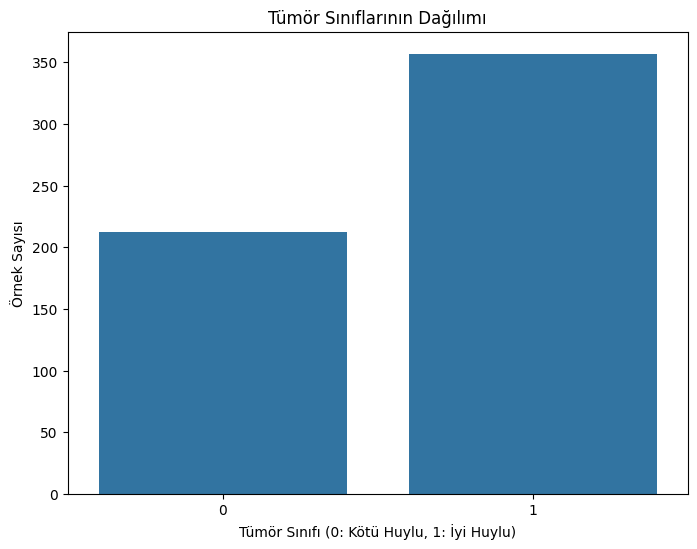

In [ ]:
# Sınıf dağılımını görselleştirelim
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df)
plt.title('Tümör Sınıflarının Dağılımı')
plt.xlabel('Tümör Sınıfı (0: Kötü Huylu, 1: İyi Huylu)')
plt.ylabel('Örnek Sayısı')
plt.show()

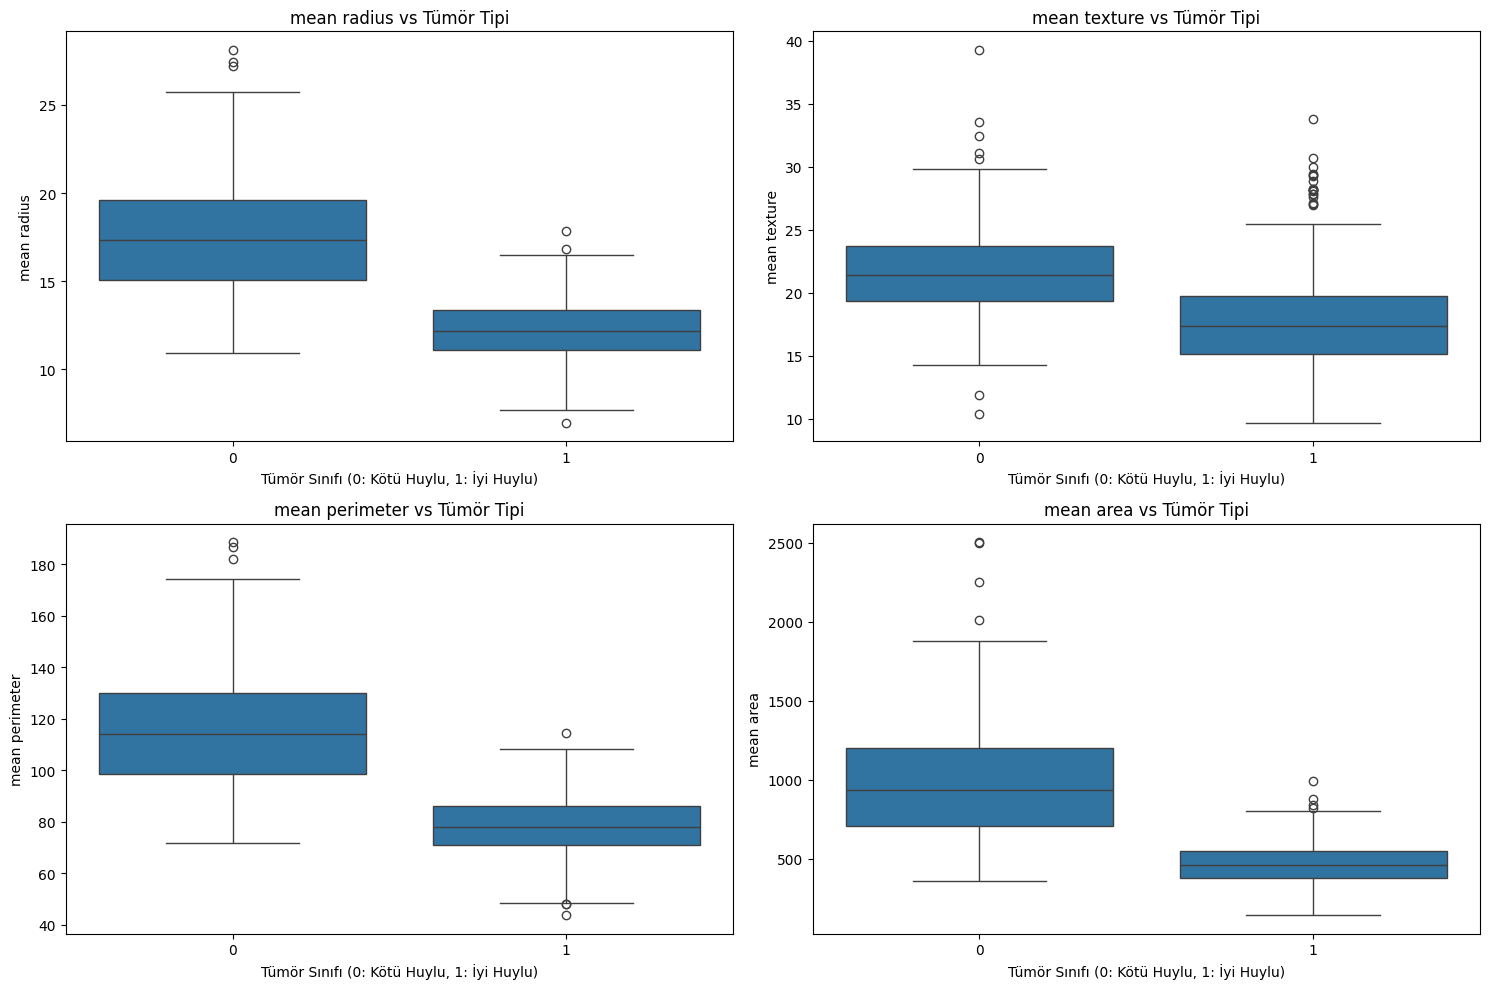

In [ ]:
# 4 özelliği kutu grafiği ile inceleyelim
plt.figure(figsize=(15, 10))

features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='target', y=feature, data=df)
    plt.title(f'{feature} vs Tümör Tipi')
    plt.xlabel('Tümör Sınıfı (0: Kötü Huylu, 1: İyi Huylu)')

plt.tight_layout()
plt.show()

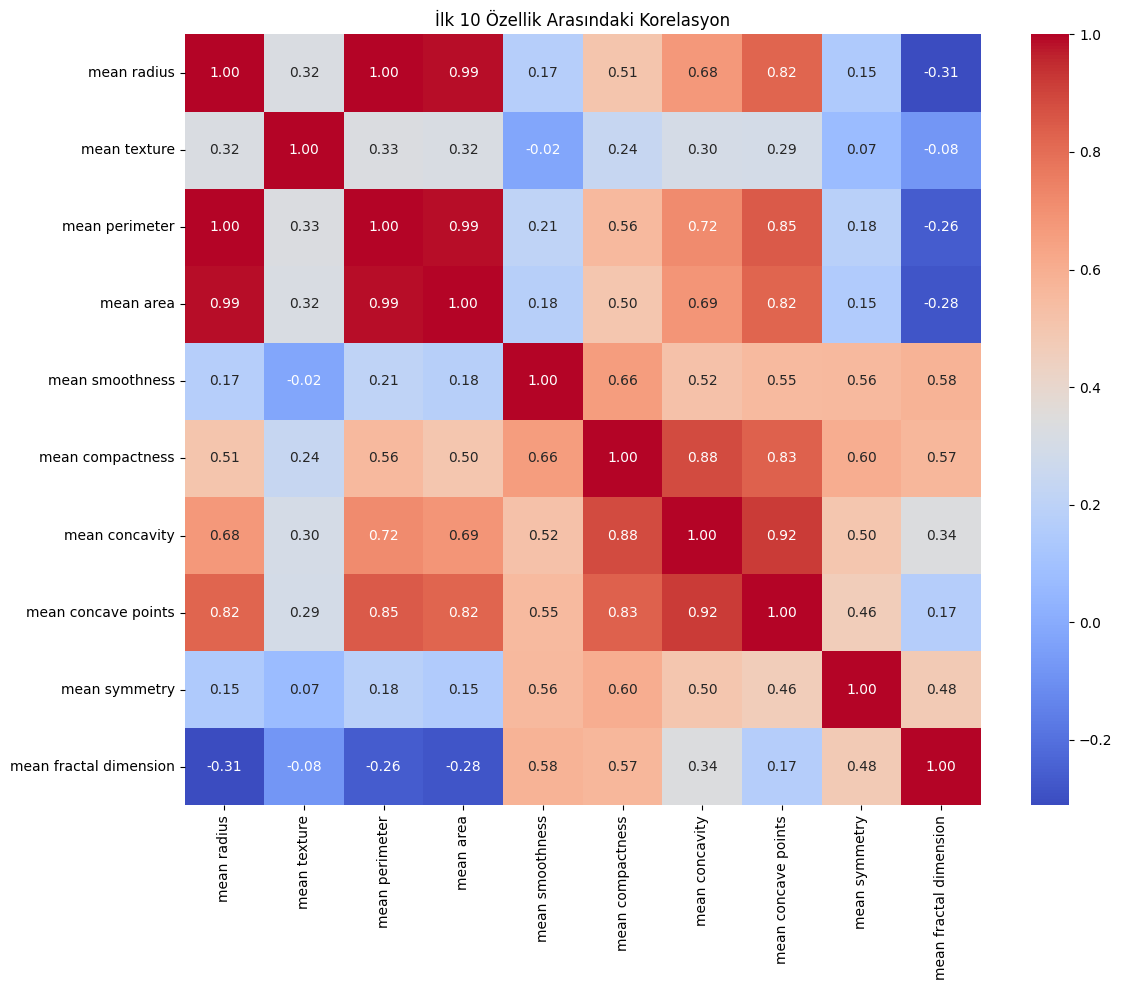

In [ ]:
# İlk 10 özellik için korelasyon haritası
plt.figure(figsize=(12, 10))
correlation = df.iloc[:, :10].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('İlk 10 Özellik Arasındaki Korelasyon')
plt.tight_layout()
plt.show()

In [ ]:
# Özellikler ve hedef değişkeni ayıralım
X = df.drop('target', axis=1)
y = df['target']

# Veriyi eğitim ve test setlerine ayıralım
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)
print("Eğitim seti sınıf dağılımı:", np.bincount(y_train))
print("Test seti sınıf dağılımı:", np.bincount(y_test))

Eğitim seti boyutu: (455, 30)
Test seti boyutu: (114, 30)
Eğitim seti sınıf dağılımı: [169 286]
Test seti sınıf dağılımı: [43 71]


In [ ]:
# Lojistik Regresyon
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Lojistik Regresyon Accuracy:", lr_accuracy)

Lojistik Regresyon Accuracy: 0.956140350877193


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Karar Ağacı
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Karar Ağacı Accuracy:", dt_accuracy)

Karar Ağacı Accuracy: 0.9473684210526315


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9649122807017544


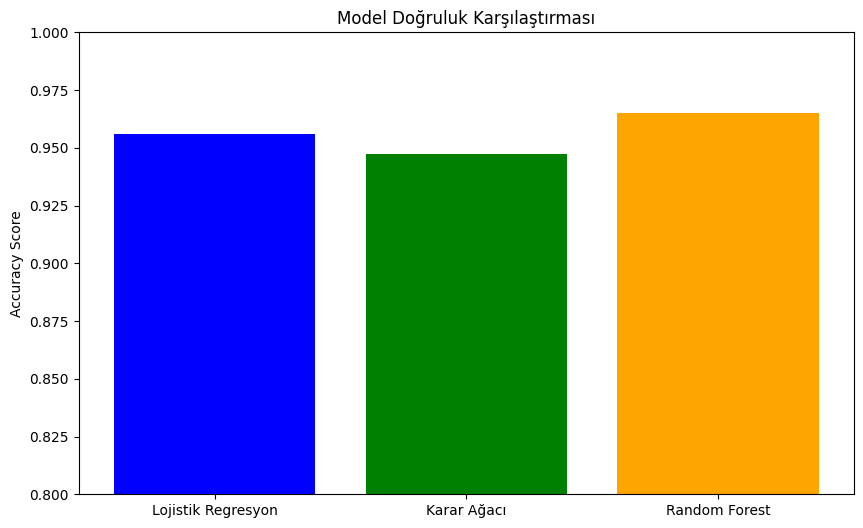

Lojistik Regresyon Accuracy: 0.9561
Karar Ağacı Accuracy: 0.9474
Random Forest Accuracy: 0.9649


In [ ]:
# Accuracy değerlerini toplayalım
accuracy_scores = {
    'Lojistik Regresyon': lr_accuracy,
    'Karar Ağacı': dt_accuracy,
    'Random Forest': rf_accuracy
}

# Grafik oluşturalım
plt.figure(figsize=(10, 6))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color=['blue', 'green', 'orange'])
plt.title('Model Doğruluk Karşılaştırması')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 1)
plt.show()

# Değerleri yazdıralım
for model, acc in accuracy_scores.items():
    print(f"{model} Accuracy: {acc:.4f}")

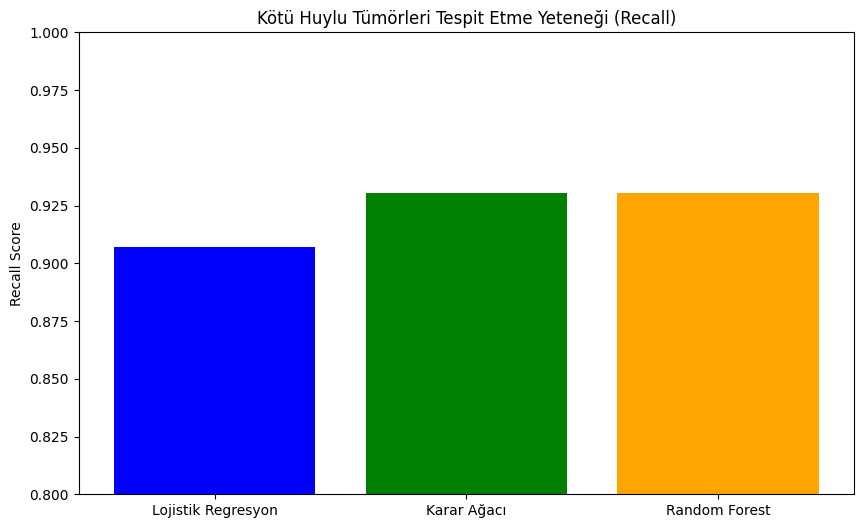

Lojistik Regresyon Recall: 0.9070
Karar Ağacı Recall: 0.9302
Random Forest Recall: 0.9302


In [ ]:
from sklearn.metrics import recall_score

# Kötü huylu tümörler için recall (pos_label=0)
recall_scores = {
    'Lojistik Regresyon': recall_score(y_test, lr_pred, pos_label=0),
    'Karar Ağacı': recall_score(y_test, dt_pred, pos_label=0),
    'Random Forest': recall_score(y_test, rf_pred, pos_label=0)
}

# Grafik
plt.figure(figsize=(10, 6))
plt.bar(recall_scores.keys(), recall_scores.values(), color=['blue', 'green', 'orange'])
plt.title('Kötü Huylu Tümörleri Tespit Etme Yeteneği (Recall)')
plt.ylabel('Recall Score')
plt.ylim(0.8, 1)
plt.show()

for model, recall in recall_scores.items():
    print(f"{model} Recall: {recall:.4f}")

In [ ]:
from sklearn.metrics import precision_score

# Kötü huylu tümörler için precision (pos_label=0)
precision_scores = {
    'Lojistik Regresyon': precision_score(y_test, lr_pred, pos_label=0),
    'Karar Ağacı': precision_score(y_test, dt_pred, pos_label=0),
    'Random Forest': precision_score(y_test, rf_pred, pos_label=0)
}

for model, precision in precision_scores.items():
    print(f"{model} Precision: {precision:.4f}")

Lojistik Regresyon Precision: 0.9750
Karar Ağacı Precision: 0.9302
Random Forest Precision: 0.9756


In [ ]:
from sklearn.metrics import f1_score

# F1-Score hesapla
f1_scores = {
    'Lojistik Regresyon': f1_score(y_test, lr_pred, pos_label=0),
    'Karar Ağacı': f1_score(y_test, dt_pred, pos_label=0),
    'Random Forest': f1_score(y_test, rf_pred, pos_label=0)
}

# Tüm metrikleri tabloya topla
comparison_df = pd.DataFrame({
    'Model': list(accuracy_scores.keys()),
    'Accuracy': list(accuracy_scores.values()),
    'Recall': list(recall_scores.values()),
    'Precision': list(precision_scores.values()),
    'F1-Score': list(f1_scores.values())
})

print("Model Karşılaştırma Tablosu:")
print(comparison_df)

Model Karşılaştırma Tablosu:
                Model  Accuracy    Recall  Precision  F1-Score
0  Lojistik Regresyon  0.956140  0.906977   0.975000  0.939759
1         Karar Ağacı  0.947368  0.930233   0.930233  0.930233
2       Random Forest  0.964912  0.930233   0.975610  0.952381



==================== LOJISTIK REGRESYON SONUÇLARI ====================
Doğruluk Oranı (Accuracy): 0.9561

Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



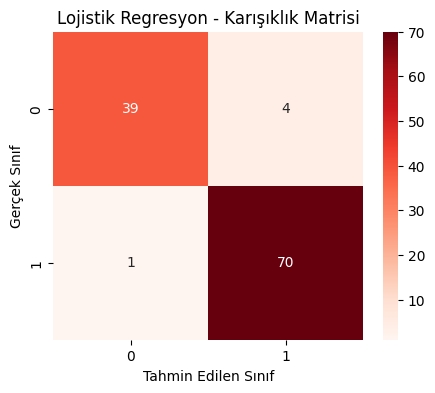


==================== KARAR AĞACI SONUÇLARI ====================
Doğruluk Oranı (Accuracy): 0.9474

Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



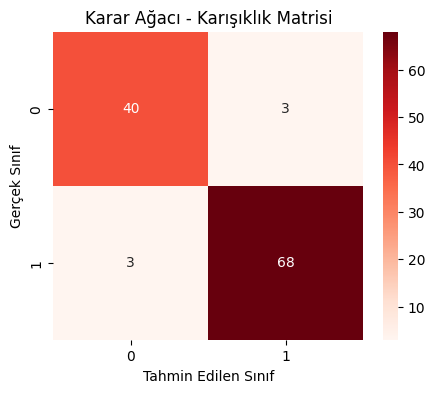


==================== RANDOM FOREST SONUÇLARI ====================
Doğruluk Oranı (Accuracy): 0.9649

Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



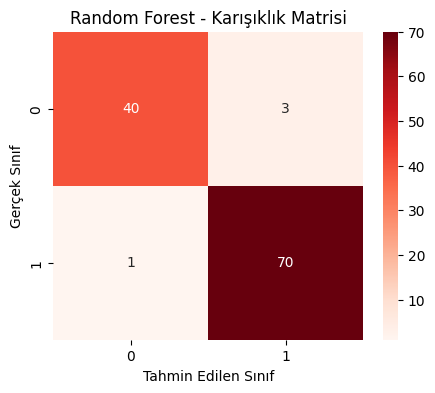

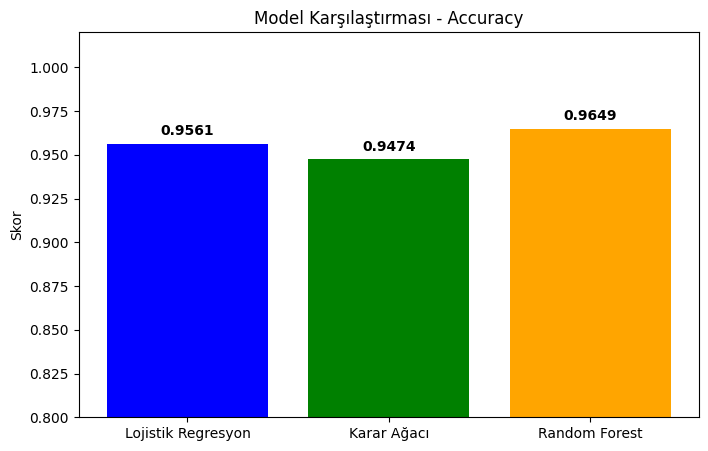

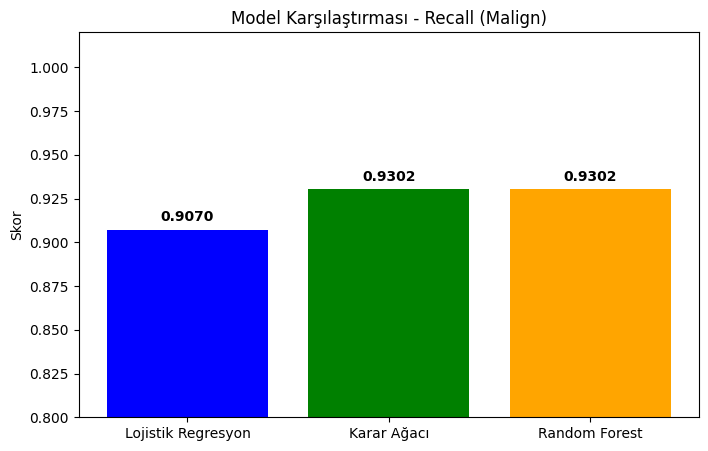

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# [Varsayım: X ve y verilerin yüklü ve train_test_split yapılmış durumda]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelleri tanımlayalım
models = {
    'Lojistik Regresyon': LogisticRegression(max_iter=3000),
    'Karar Ağacı': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Metrikleri saklamak için sözlükler
accuracy_scores = {}
recall_scores = {}
precision_scores = {}
f1_scores = {}

# Her modeli eğitip çıktıları alalım
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrikleri hesaplama (Kötü huylu / Malign tümörler için: pos_label=0)
    accuracy_scores[name] = accuracy_score(y_test, y_pred)
    recall_scores[name] = recall_score(y_test, y_pred, pos_label=0)
    precision_scores[name] = precision_score(y_test, y_pred, pos_label=0)
    f1_scores[name] = f1_score(y_test, y_pred, pos_label=0)

    # 1. İstenen Çıktılar: Konsola Yazdırma
    print(f"\n==================== {name.upper()} SONUÇLARI ====================")
    print(f"Doğruluk Oranı (Accuracy): {accuracy_scores[name]:.4f}")
    print("\nSınıflandırma Raporu (Classification Report):")
    print(classification_report(y_test, y_pred))

    # Karışıklık Matrisi (Confusion Matrix) Görselleştirme
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
    plt.title(f'{name} - Karışıklık Matrisi')
    plt.ylabel('Gerçek Sınıf')
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.show()

# 2. İstenen Çıktılar: Senin Paylaştığın Karşılaştırma Grafikleri
metrics_to_plot = {'Accuracy': accuracy_scores, 'Recall (Malign)': recall_scores}

for title, score_dict in metrics_to_plot.items():
    plt.figure(figsize=(8, 5))
    plt.bar(score_dict.keys(), score_dict.values(), color=['blue', 'green', 'orange'])
    plt.title(f'Model Karşılaştırması - {title}')
    plt.ylabel('Skor')
    plt.ylim(0.8, 1.02)
    for i, v in enumerate(score_dict.values()):
        plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
    plt.show()

In [ ]:
!nvidia-smi

Thu May 21 13:12:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!unzip -o iris.zip

Archive:  iris.zip
  inflating: __MACOSX/._iris         
  inflating: iris/iris.names         
  inflating: __MACOSX/iris/._iris.names  
  inflating: iris/iris.data          
  inflating: __MACOSX/iris/._iris.data  
  inflating: iris/bezdekIris.data    
  inflating: __MACOSX/iris/._bezdekIris.data  
  inflating: iris/Index              
  inflating: __MACOSX/iris/._Index   


In [ ]:
import pandas as pd

df = pd.read_csv("iris/bezdekIris.data",
                 sep=",",
                 header=None,
                 names=["sepal_length", "sepal_width",
                        "petal_length", "petal_width", "species"])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Veri setinin boyutunu (satır ve sütun sayısını) gösterir
df.shape

(150, 5)

In [ ]:
# Veri setindeki sütun isimlerini gösterir
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [ ]:
# Veri setinin sayısal istatistiklerini gösterir
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Veri seti hakkında genel bilgileri gösterir
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# Her sütundaki eksik değer sayısını gösterir
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


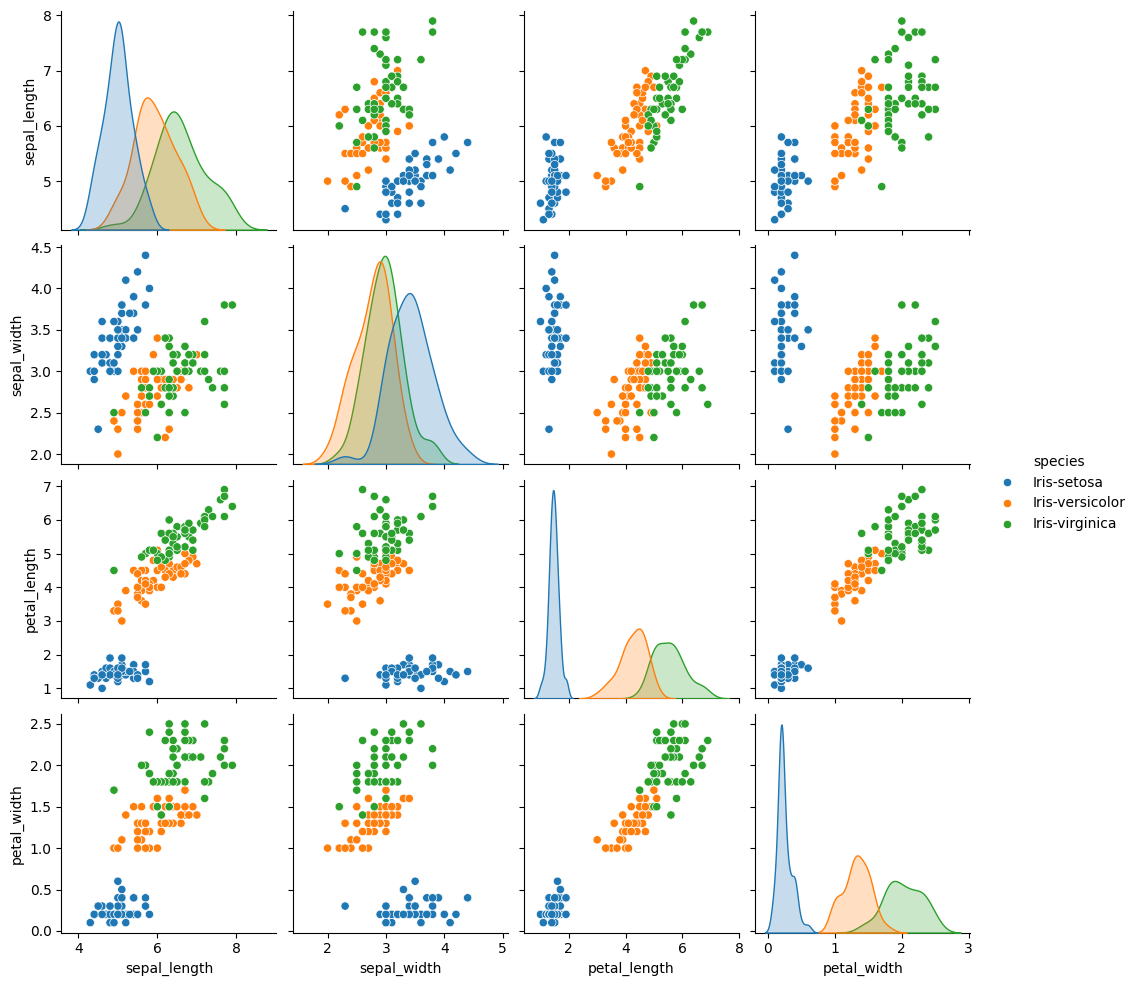

In [ ]:
# Gerekli kütüphaneleri içe aktaralım
import seaborn as sns
import matplotlib.pyplot as plt

# Tüm özelliklerin birbiriyle ilişkisini gösteren pairplot
sns.pairplot(df, hue="species")
plt.show()

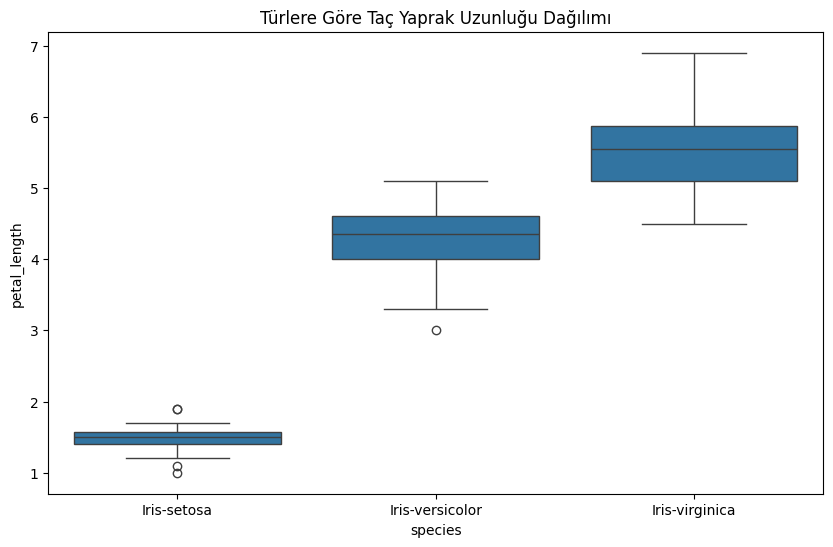

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x="species", y="petal_length", data=df)
plt.title("Türlere Göre Taç Yaprak Uzunluğu Dağılımı")
plt.show()

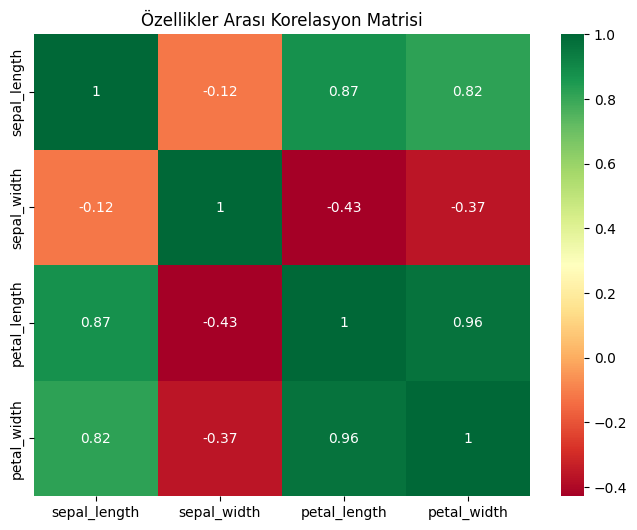

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Sadece sayısal sütunları seçerek korelasyon hesaplıyoruz
correlation = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation, annot=True, cmap='RdYlGn')
plt.title("Özellikler Arası Korelasyon Matrisi")
plt.show()

/tmp/ipykernel_9840/613087679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='viridis')


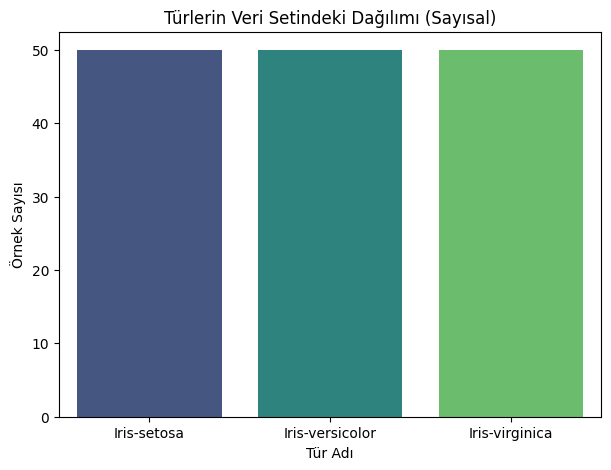

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.countplot(x='species', data=df, palette='viridis')
plt.title('Türlerin Veri Setindeki Dağılımı (Sayısal)')
plt.ylabel('Örnek Sayısı')
plt.xlabel('Tür Adı')
plt.show()

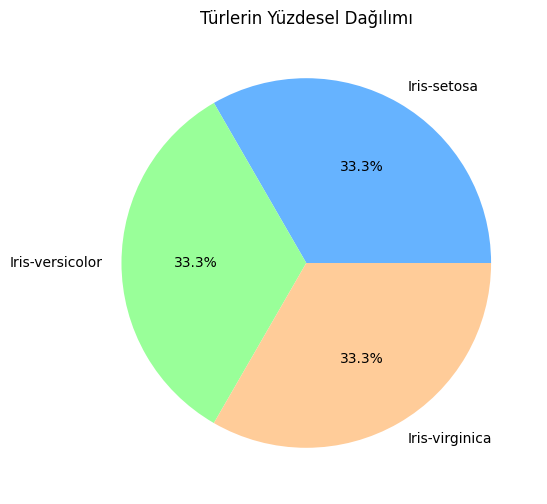

In [ ]:
import matplotlib.pyplot as plt

# Tür sayılarını alalım
species_counts = df['species'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(species_counts, labels=species_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ffcc99'])
plt.title('Türlerin Yüzdesel Dağılımı')
plt.show()

In [ ]:
# Gerekli kütüphaneleri içe aktar
import pandas as pd
from sklearn.datasets import load_iris

# Iris veri setini yükle
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# İlk 5 satırı kontrol et
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Eğitim seti boyutu: {X_train.shape[0]} örnek')
print(f'Test seti boyutu: {X_test.shape[0]} örnek')

Eğitim seti boyutu: 120 örnek
Test seti boyutu: 30 örnek


In [ ]:
# Lojistik Regresyon modelini içe aktarma
from sklearn.linear_model import LogisticRegression

# Modeli oluşturma
model = LogisticRegression(max_iter=200)

# Modeli eğitim verileriyle eğitme
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
# Test verilerine dayalı tahminler yapma
y_pred = model.predict(X_test)

# Model başarısını ölçme
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


In [ ]:
# Karar Ağacı modelini içe aktarma
from sklearn.tree import DecisionTreeClassifier

# Modeli oluşturma
model = DecisionTreeClassifier(random_state=42)

# Eğit, tahmin et, başarıyı ölç
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Karar Ağacı Accuracy:", acc)

Karar Ağacı Accuracy: 1.0


In [ ]:
# Rastgele Orman modelini içe aktarma
from sklearn.ensemble import RandomForestClassifier

# Modeli oluşturma (100 ağaç)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Eğit, tahmin et, başarıyı ölç
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Rastgele Orman Accuracy:", acc)

Rastgele Orman Accuracy: 1.0


In [ ]:
# SVM modelini içe aktarma
from sklearn.svm import SVC

# Modeli oluşturma
model = SVC(random_state=42)

# Eğit, tahmin et, başarıyı ölç
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("SVM Accuracy:", acc)

SVM Accuracy: 1.0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Test edilecek modeller
models = {
    'Lojistik Regresyon': LogisticRegression(max_iter=200),
    'Karar Ağacı': DecisionTreeClassifier(random_state=42),
    'Rastgele Orman': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
}

# Her modeli eğit ve test et
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")

Lojistik Regresyon Accuracy: 1.0000
Karar Ağacı Accuracy: 1.0000
Rastgele Orman Accuracy: 1.0000
SVM Accuracy: 1.0000


Eğitim seti boyutu: 120 örnek
Test seti boyutu: 30 örnek

--------------------------------------------------

[ LOJİSTİK REGRESYON SONUÇLARI ]
Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



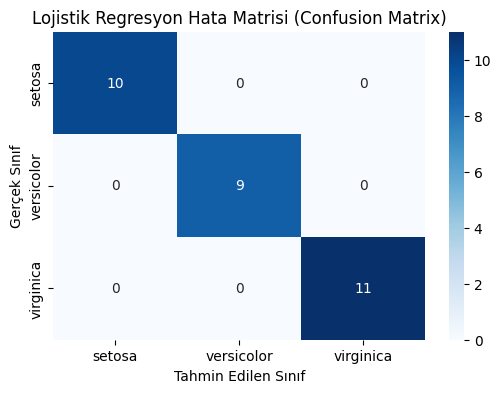

--------------------------------------------------


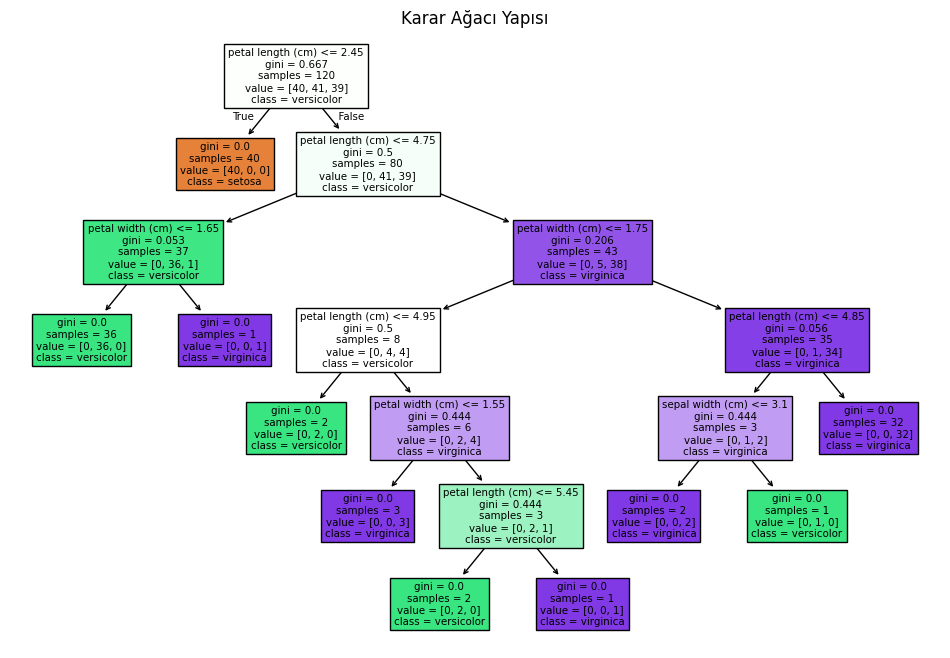

--------------------------------------------------

[ MODEL KARŞILAŞTIRMA SONUÇLARI ]
Lojistik Regresyon Accuracy: 1.0000
Karar Ağacı Accuracy: 1.0000
Rastgele Orman Accuracy: 1.0000
SVM Accuracy: 1.0000


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Bölme (Senin kodun)
X = df.drop('species', axis=1)
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Eğitim seti boyutu: {X_train.shape[0]} örnek')
print(f'Test seti boyutu: {X_test.shape[0]} örnek\n')
print("-" * 50)

# ==========================================
# 1. LOJİSTİK REGRESYON SINIFLANDIRMASI
# ==========================================
print("\n[ LOJİSTİK REGRESYON SONUÇLARI ]")
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix Görselleştirme
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=log_model.classes_, yticklabels=log_model.classes_)
plt.title('Lojistik Regresyon Hata Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

print("-" * 50)

# ==========================================
# 2. KARAR AĞACI SINIFLANDIRMASI
# ==========================================
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Ağacı Görselleştirme
plt.figure(figsize=(12,8))
plot_tree(dt_model, feature_names=X.columns, class_names=dt_model.classes_, filled=True)
plt.title("Karar Ağacı Yapısı")
plt.show()

print("-" * 50)

# ==========================================
# 3. TÜM MODELLERİN KARŞILAŞTIRILMASI
# ==========================================
print("\n[ MODEL KARŞILAŞTIRMA SONUÇLARI ]")
models = {
    'Lojistik Regresyon': LogisticRegression(max_iter=200),
    'Karar Ağacı': DecisionTreeClassifier(random_state=42),
    'Rastgele Orman': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")

In [ ]:
# 3. TÜM MODELLERİN KARŞILAŞTIRILMASI
# ==========================================
print("\n[ MODEL KARŞILAŞTIRMA SONUÇLARI ]")
models = {
    'Lojistik Regresyon': LogisticRegression(max_iter=200),
    'Karar Ağacı': DecisionTreeClassifier(random_state=42),
    'Rastgele Orman': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")


[ MODEL KARŞILAŞTIRMA SONUÇLARI ]
Lojistik Regresyon Accuracy: 1.0000
Karar Ağacı Accuracy: 1.0000
Rastgele Orman Accuracy: 1.0000
SVM Accuracy: 1.0000
